In [22]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import  functions.funcs as funcs
import functions.output_functions as output 
import functions.plotting as plot
import functions.draw_forecast_cones as cones
import geopandas as gpd
import seaborn as sns
import shapely as shp
import xarray as xr
import matplotlib.animation as animation
from matplotlib.ticker import MultipleLocator
from importlib import reload 
reload(output)

<module 'functions.output_functions' from 'C:\\FATE\\Code\\functions\\output_functions.py'>

In [11]:
## load data to be plotted 
fc0 = pd.read_csv('saved_output/Final/cmems_bias_pers_meanremoved_2026.csv')
dFADs = gpd.read_parquet('../Data/SAT_MI_FAD_cleanedspeeds_2026-01-01_mapped_all.parquet')
qdata = xr.load_dataset('../Data/regression_quantiles_leadtimes_cmems_bias_pers_2026.nc')

fc0.Time = pd.to_datetime(fc0.Time)

In [20]:
# Combining the true dFAD data with the forecasted possitions
longlist = funcs.generate_longlist(dFADs, extra_columns= ['mapped_u', 'mapped_v'])
longlist = longlist.rename(columns = {'mapped_u':'u_mapped', 'mapped_v': 'v_mapped'})
merged  = output.merge_forecast_true(fc0, longlist)
merged = output.add_starttime(merged)
merged = output.calc_iniial_lat(merged)
merged = output.calc_intial_speed_dif(merged)
merged = merged.sort_values(['BuoyID', 'starttime', 'Time']).reset_index(drop = True)
IDs = merged.BuoyID.unique()
# setting quantile 
qdata['leadtime'] = (qdata.leadtime + 1)*4
q70 = qdata.sel(q= 0.7, method ='nearest')

4.6038 0.24140971461048205


AttributeError: 'GeometryCollection' object has no attribute 'exterior'

Error in callback <function _draw_all_if_interactive at 0x000001D7F91B49A0> (for post_execute), with arguments args (),kwargs {}:


AttributeError: 'GeometryCollection' object has no attribute 'exterior'

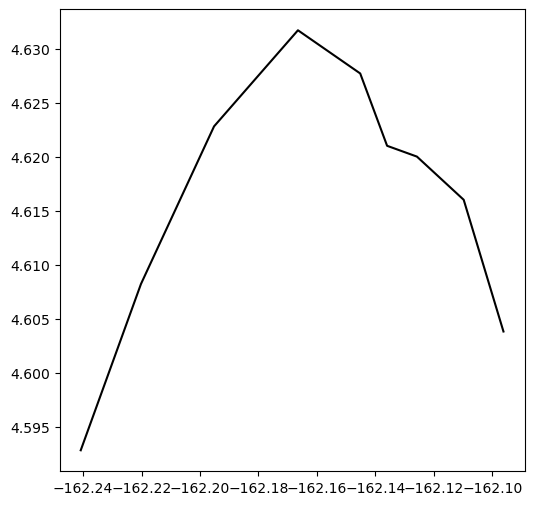

In [23]:


## Selecting what dFAd and forecast to plot
buoyID = IDs[447]
sd = 1




#getting intial angle and speed to solve error
Forecast = merged.query(f"BuoyID == @buoyID")
startdays = Forecast.query(f'leadtime == 0').reset_index(drop = True)
startday = startdays.at[sd,'Time'].round('min')
Forecast = Forecast.query(f'starttime == @startday').reset_index(drop= True)
isd = Forecast.initial_speed_dif_mag[0]
ilat = Forecast.initial_lat[0]
print(ilat, isd)
leadtimes = np.arange(Forecast.leadtime.min(), Forecast.leadtime.max()+0.001, 0.5)
#leadtimes = Forecast.leadtime
leadtimes = leadtimes[1:] ## get rid of zero 
## solving Q
qs = qdata.copy()
qs = qs.interp(leadtime = leadtimes, kwargs={"fill_value": "extrapolate"})
qs['qsolved'] = qs.initial_lat*ilat + qs.initial_speed_dif_mag*isd + qs.Intercept


## new calc a column of leatimes and error_km

fig, ax = plt.subplots(figsize=(6,6))

def update(hours):
    ax.clear()  # remove previous frame drawings
    # draw forecasts for this many days
    cones.plot_Forcasts(
        buoyID, dFADs, [merged], startday=sd,
        labels=["Forecast"],
        fig=fig, ax=ax,q= qs,
        forcastlength=pd.Timedelta(hours=hours),
        pastTrajectory=pd.Timedelta(days=7), shaded_cone= True
    )
    try:
        ax.legend( loc="upper right", bbox_to_anchor=(1,0.98), bbox_transform=ax.transAxes)
    except Exception:
        pass
    plot.Add_bathymetry(fig, ax, cbar = False)
    ax.set_aspect("equal")
    ax.text(0.75, 0.82, f"Days:{hours/24 :.2f}", bbox=dict(facecolor='white', alpha=0.5), transform=ax.transAxes)
    cones.plot_circle_km(ax, radius_km=0.0833)
    startzoom = 2*24
    endzoom = 3.5*24
    xlim_s = np.array([-163.25+0.25, -161.75+0.25])
    ylim_s = np.array([ 5,6.5])
    xlim_e = np.array([-163.25+0.25, -160.75+0.25])
    ylim_e = np.array([ 4.5,7])
    dxlim = xlim_e - xlim_s
    dylim = ylim_e - ylim_s
    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.yaxis.set_major_locator(MultipleLocator(0.5))
    if hours < 2*24: 
        ax.set(xlim = xlim_s, ylim =ylim_s)
    elif hours < endzoom: 
        ratio = (hours -startzoom)/(endzoom- startzoom)
        ax.set(xlim = xlim_s + dxlim*ratio, ylim = ylim_s + dylim*ratio)
    else:
        ax.set(xlim = xlim_e, ylim = ylim_e)

ani = animation.FuncAnimation(fig, update, frames=leadtimes, interval=100, blit=False)
ani.save(r"..\..\Figures\Animations\Forecast_cone.mp4", writer= 'ffmpeg')